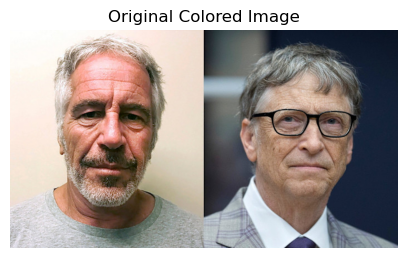

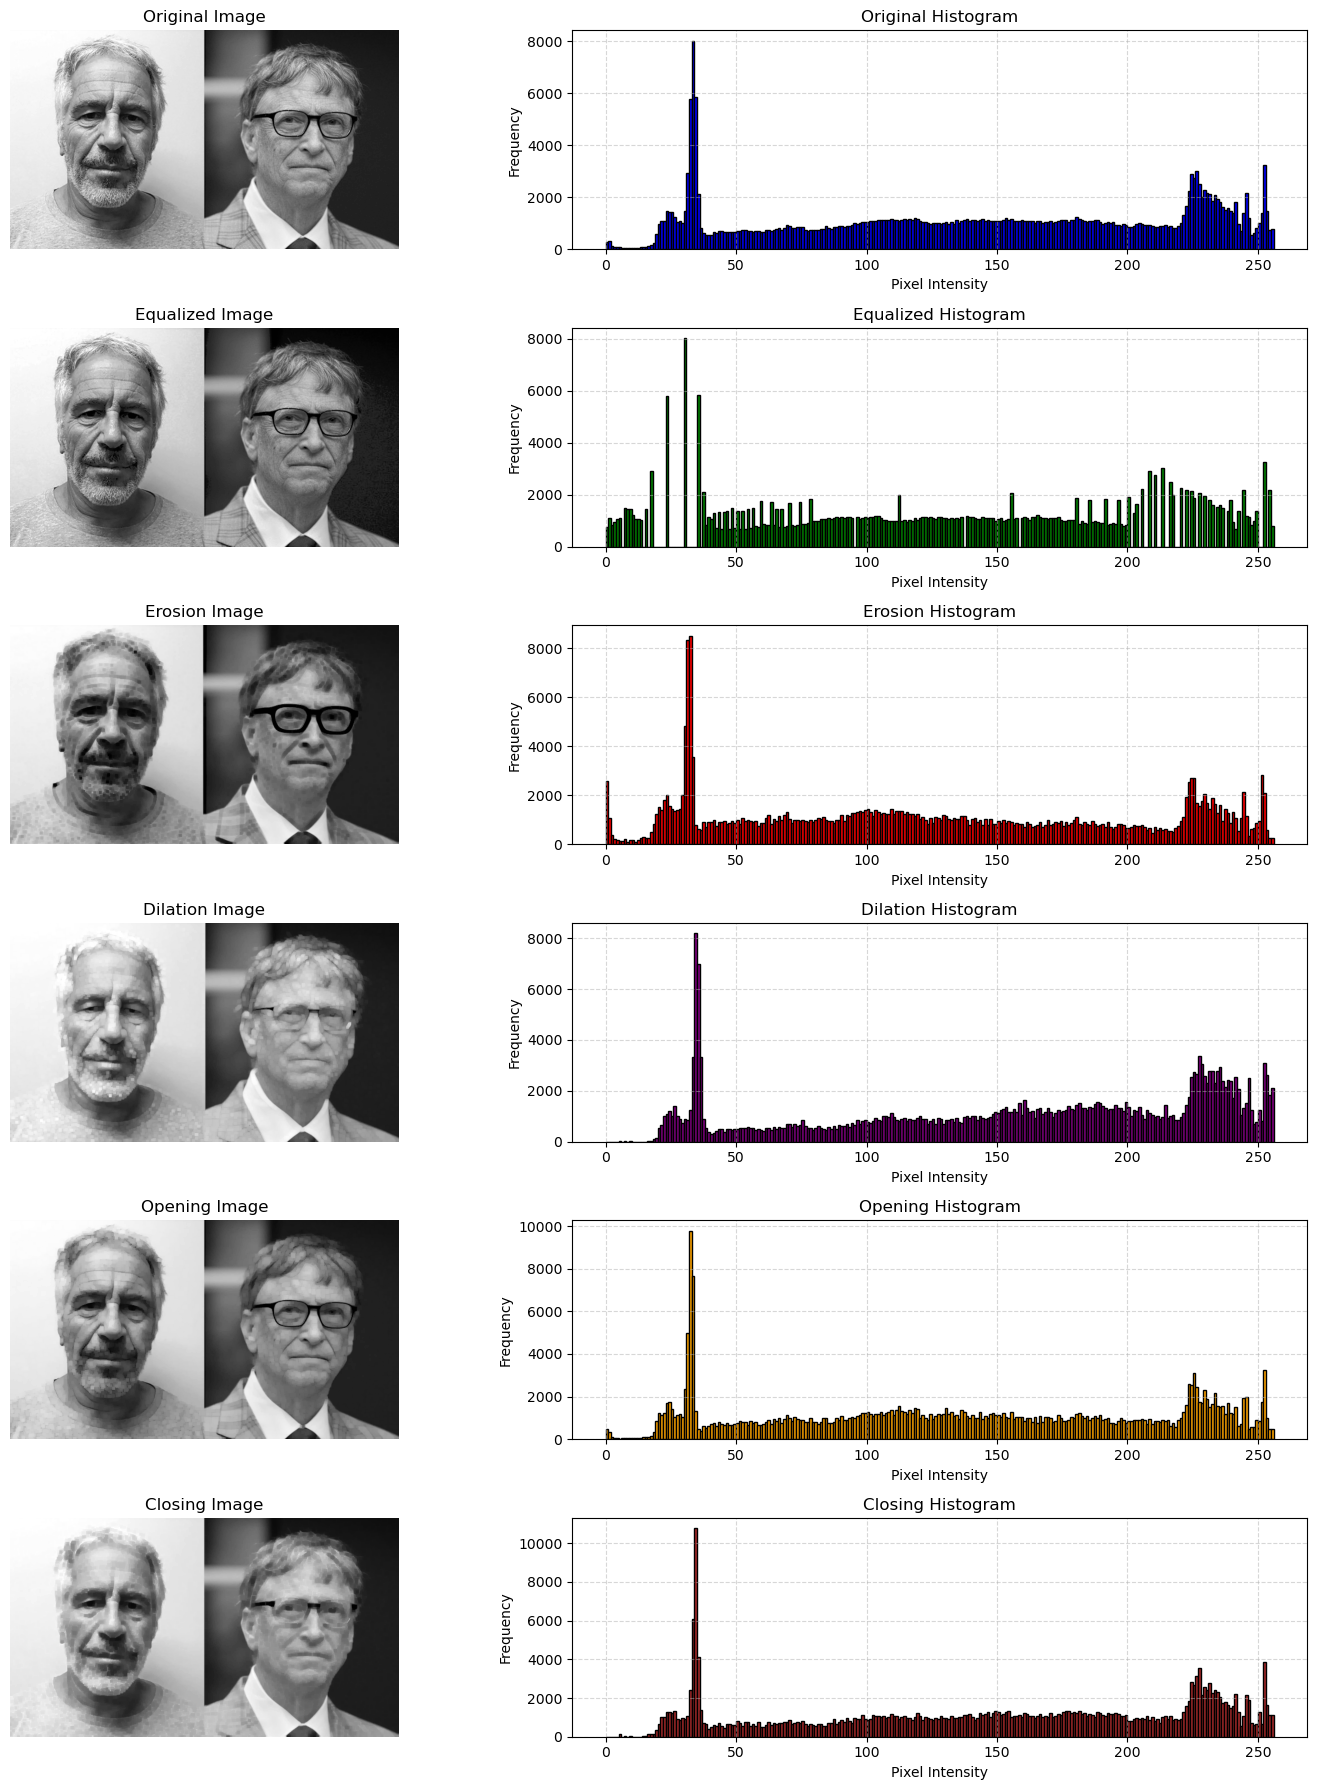

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read image in COLOUR first so we can display it colored
img_bgr = cv2.imread("sample.jpg")

if img_bgr is None:
    print("Error: sample.jpg not found!")
    exit()
else:
    # 2. Convert from BGR to RGB for proper color rendering
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 3. Display the original colored image immediately
    plt.figure(figsize=(5, 5))
    plt.imshow(img_rgb)  
    plt.title("Original Colored Image")
    plt.axis('off')
    plt.show()

# 4. Now convert it to grayscale for all the lab processing steps
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Histogram Equalization
equalized = cv2.equalizeHist(img) #[cite: 1]

# Kernel
kernel = np.ones((5,5), np.uint8) #[cite: 1]

# Morphological Operations
erosion = cv2.erode(img, kernel, iterations=1) #[cite: 1]
dilation = cv2.dilate(img, kernel, iterations=1) #[cite: 1]
opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel) #[cite: 1]
closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel) #[cite: 1]

# Images, Titles and Colors
images = [img, equalized, erosion, dilation, opening, closing]
titles = ["Original", "Equalized", "Erosion", "Dilation", "Opening", "Closing"]
colors = ["blue", "green", "red", "purple", "orange", "brown"]

# Display Images and Histograms side-by-side
plt.figure(figsize=(15,18))

for i in range(len(images)):
    # Display Image
    plt.subplot(6,2,2*i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i] + " Image")
    plt.axis('off')

    # Display Histogram
    plt.subplot(6,2,2*i+2)
    plt.hist(
        images[i].ravel(),
        bins=256,
        range=(0,256),
        color=colors[i],
        edgecolor='black'
    )
    plt.title(titles[i] + " Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [10]:
!dir


 Volume in drive C has no label.
 Volume Serial Number is FCC0-4EC9

 Directory of C:\Users\Student\23ad038

13-07-2026  12:01    <DIR>          .
13-07-2026  11:04    <DIR>          ..
13-07-2026  11:46    <DIR>          .ipynb_checkpoints
13-07-2026  12:01         1,075,273 processed.ipynb
13-07-2026  11:42            82,537 sample.jpg
13-07-2026  11:48               589 Untitled.ipynb
               3 File(s)      1,158,399 bytes
               3 Dir(s)  129,450,860,544 bytes free
